In [105]:
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch

In [106]:
eta = 0.1
S_0 = 3
mu = 0.05
sigma = 0.2

T = 1
M = 10
N = 100

In [107]:
S = np.zeros(shape=(M+1,N))
dt = T/M
S[0,:] = S_0
for t in range(1,M+1):
    S[t,:] = S[t-1,:]+mu*(S[t-1,:]+eta)*dt+sigma*(S[t-1,:]+eta)*np.sqrt(dt)*np.random.normal(0,1,N)
    

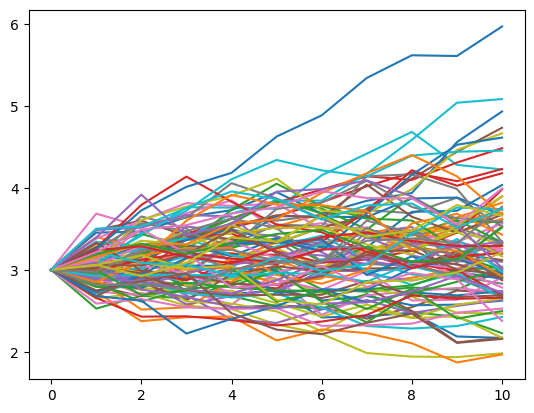

In [108]:
plt.plot(S)
plt.show()

In [109]:
def u(x):
    return 1-torch.exp(-x)

lr = 1e-3
batchsize = int(N/10)
epochs = 100

In [110]:
models = []
opts = []
for j in range(M):
    m = nn.Sequential(
        nn.Linear(j+1,8),
        nn.ReLU(),
        nn.Linear(8,8),
        nn.ReLU(),
        nn.Linear(8,1)
    ).double()
    models.append(m)
    opts.append(torch.optim.SGD(m.parameters(),lr=lr))

In [111]:
models[1](torch.from_numpy(S[0:2,0]))

tensor([0.1733], dtype=torch.float64, grad_fn=<ViewBackward0>)

In [112]:
loss_evo = []

In [113]:
for e in range(1,epochs+1):
    order = torch.randperm(N)
    loss_evob =[]
    for b in range(0,N,batchsize):
        for opt in opts:
            opt.zero_grad()
        L = 0
        for i in order[b:b+batchsize]:
            X = [torch.tensor([0],dtype=torch.float64)]
            for j in range(1,M+1):
                I = torch.from_numpy(S[0:j,i])
                H = models[j-1](I)
                X_ = X[-1]+H*(S[j,i]-S[j-1,i])
                X.append(X_)
            L = L-u(X_)
        L = L/batchsize
        L.backward()
        loss_evob.append(L.detach())

        for opt in opts:
            opt.step()
    loss_evo.append(np.mean(loss_evob))

    if e % 5 == 0:
        print(f"Epoch #{e}, Loss={loss_evo[e-1]}")
        

Epoch #5, Loss=0.0038776995488517554
Epoch #10, Loss=-0.0002436291687080108
Epoch #15, Loss=-0.004077485086423737
Epoch #20, Loss=-0.007810861076539282
Epoch #25, Loss=-0.011321672601087214
Epoch #30, Loss=-0.014748606645933754
Epoch #35, Loss=-0.017938641092264236
Epoch #40, Loss=-0.0211073660134942
Epoch #45, Loss=-0.02411393526645289
Epoch #50, Loss=-0.02699505601239031
Epoch #55, Loss=-0.029852562220539787
Epoch #60, Loss=-0.03255513310279903
Epoch #65, Loss=-0.0351717161470656
Epoch #70, Loss=-0.03776206586644105
Epoch #75, Loss=-0.04026104483549055
Epoch #80, Loss=-0.04266814822842367
Epoch #85, Loss=-0.045010912754008564
Epoch #90, Loss=-0.04728404339707468
Epoch #95, Loss=-0.049538744085399274
Epoch #100, Loss=-0.051651493664607515


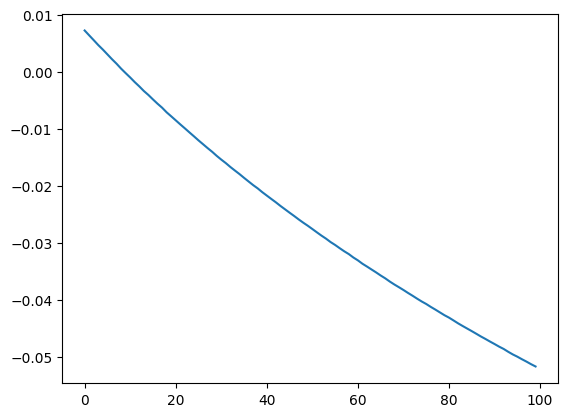

In [114]:
plt.plot(loss_evo)
plt.show()

In [115]:
S = np.zeros(shape=(M+1,N))
dt = T/M
S[0,:] = S_0
for t in range(1,M+1):
    S[t,:] = S[t-1,:]+mu*(S[t-1,:]+eta)*dt+sigma*(S[t-1,:]+eta)*np.sqrt(dt)*np.random.normal(0,1,N)
    

In [116]:
endU = np.zeros(shape=(M+1,N))
for i in range(N):
    X = [torch.tensor([0],dtype=torch.float64)]
    for j in range(1,M+1):
        I = torch.from_numpy(S[0:j,i])
        H = models[j-1](I)
        X_ = X[-1]+H*(S[j,i]-S[j-1,i])
        endU[j,i] = (u(X_).detach())

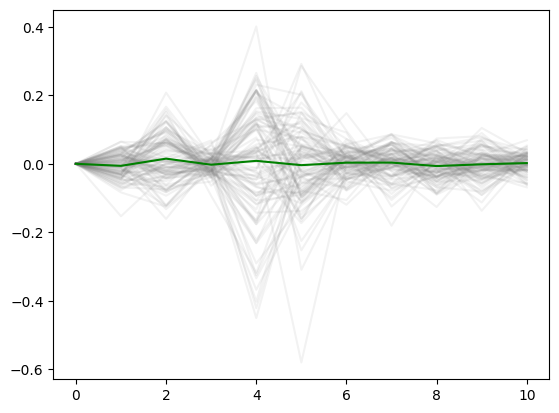

In [117]:
plt.plot(endU,color="grey",alpha=0.1)
plt.plot(np.mean(endU,axis=1),color="green")
plt.show()

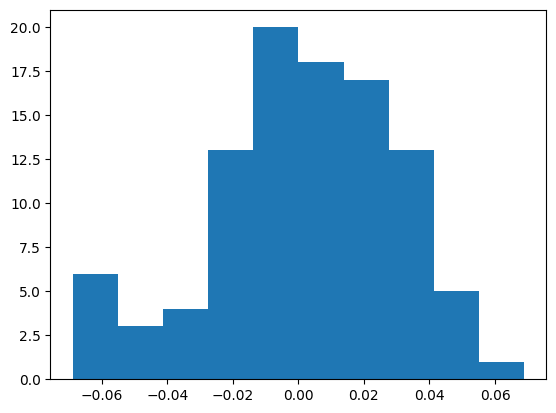

In [118]:
plt.hist(endU[-1,:])
plt.show()